### Visualization tools

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Reward over time plot

obs = np.load('./observations.npy')
T, n = obs.shape

strategy_string = "Tsallis-INF"

max_reward = np.zeros(T-1)
for t in range(1,T):
    max_reward[t-1] =np.sum(np.max(obs[:t,:], axis = 0)) 

plt.plot(range(1, T), max_reward/n, label = "Reward")
plt.grid()
plt.legend()
plt.ylim([0.7, 1])
plt.xlabel('t')
plt.ylabel("Reward")
plt.title(f'Maximum average reward, using the {strategy_string} strategy')
plt.show()
#plt.savefig('./tsallis_inf_reward_rf1.svg', format ="svg" )

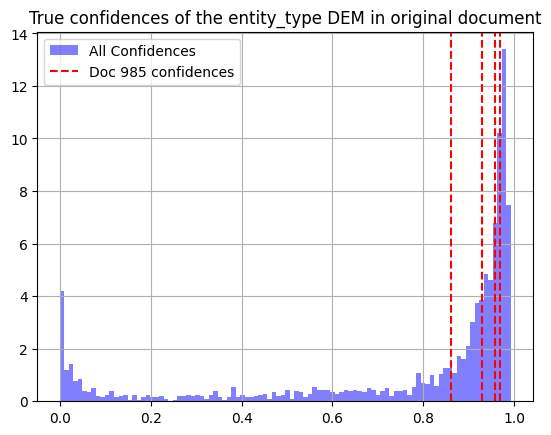

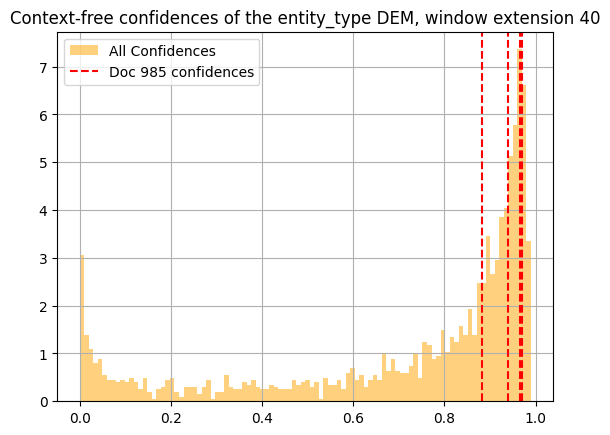

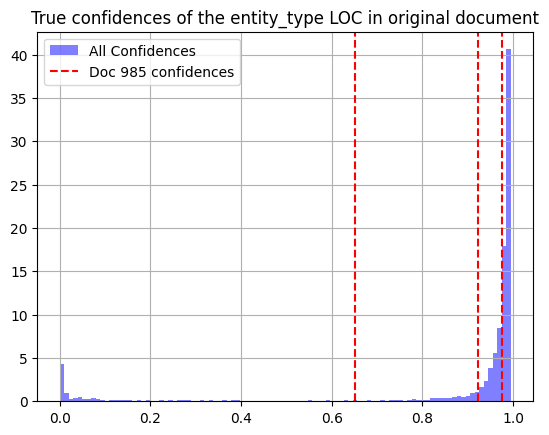

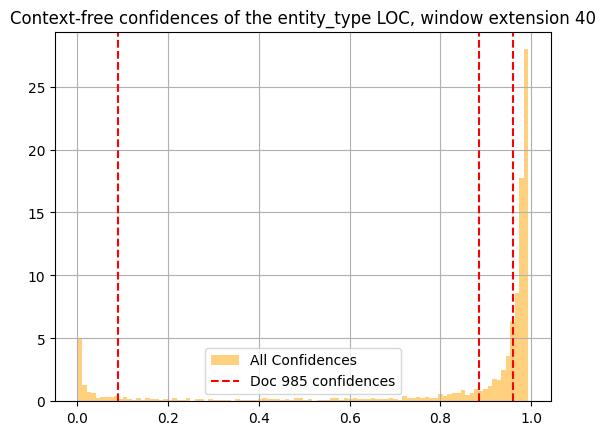

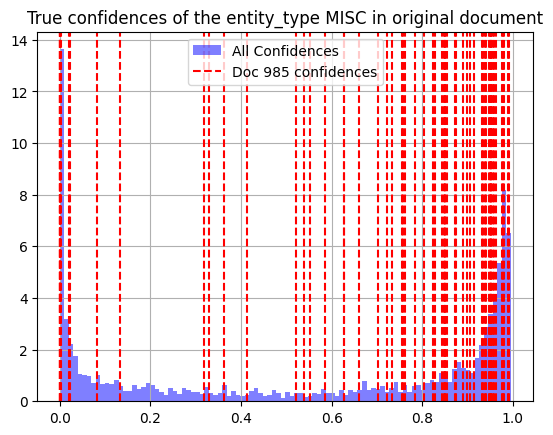

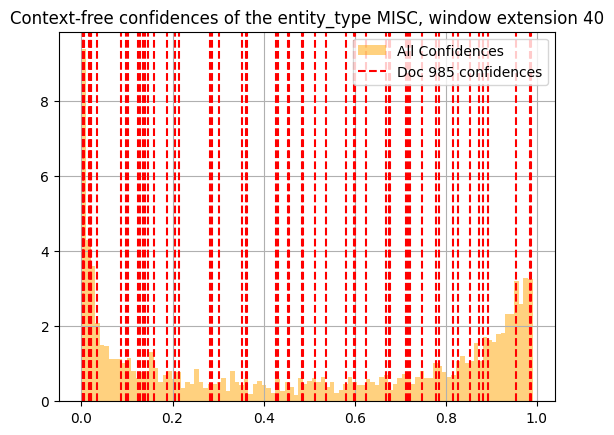

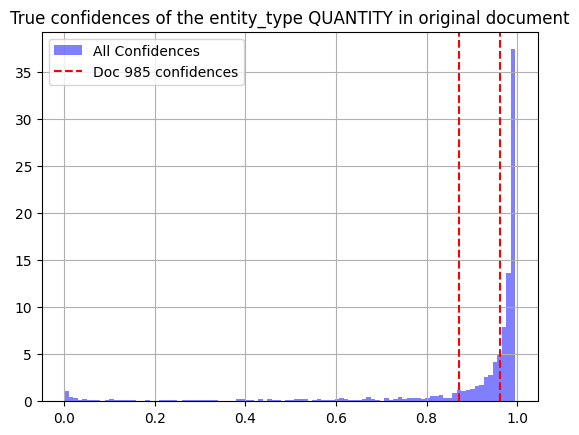

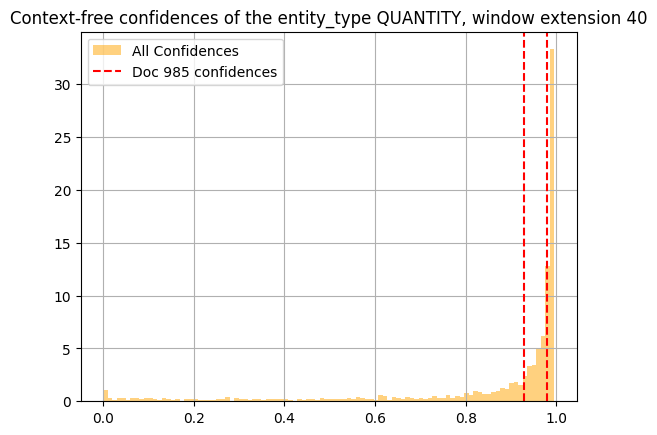

In [15]:
import numpy as np
import matplotlib.pyplot as plt

entity_string_to_int  = {
    'O': -1,
    'PERSON': 0,
    'CODE': 1,
    'LOC': 2,
    'ORG': 3,
    'DEM': 4,
    'DATETIME': 5,
    'QUANTITY': 6,
    'MISC': 7
}
entity_types_of_interest = ["QUANTITY", 'MISC', 'DEM', 'LOC']
entity_int_to_string = {v: k for k, v in entity_string_to_int.items()}    

attack_type_all = 'bandit'
attack_type_single = 'random'
experiment_output_folder = '/Users/reimera/Desktop/alvis/projects/LeakPro/examples/extraction_attacks/experiment_outputs'

window_extension = 40
doc_id = 985

if window_extension == 0:
    path_to_data = '/Users/reimera/Desktop/alvis/projects/LeakPro/examples/extraction_attacks' # For the original context free
else: 
    path_to_data = experiment_output_folder + f'/250904/1611_{attack_type_all}_gather_stats_size_ext_{window_extension}'

single_doc_overlay = True
if single_doc_overlay:
    path_to_single_doc_data = experiment_output_folder + f'/250912/0817_{attack_type_single}_gather_stats_size_ext_{window_extension}'
    entity_wise_true_probs_single = np.load( path_to_single_doc_data + f'/entity_wise_probs_doc_{doc_id}.npy', allow_pickle=True).item()
    true_probs_single = np.load( path_to_single_doc_data + f'/true_probs_of_all_dict_doc_{doc_id}.npy', allow_pickle=True).item()
    entity_labels_single, entity_hist_single = zip(*entity_wise_true_probs_single.items())
    true_labels_single, true_hist_single = zip(*true_probs_single.items())
    entity_labels_single = [entity_int_to_string[el] for el in entity_labels_single]
    true_labels_single = [entity_int_to_string[el] for el in true_labels_single]

entity_wise_true_probs = np.load( path_to_data + '/entity_wise_probs.npy', allow_pickle=True).item() 
true_probs = np.load( path_to_data + '/true_probs_of_all_dict.npy', allow_pickle=True).item() 

entity_labels, entity_hist = zip(*entity_wise_true_probs.items())
true_labels, true_hist = zip(*true_probs.items())

entity_labels = [entity_int_to_string[el] for el in entity_labels]
true_labels = [entity_int_to_string[el] for el in true_labels]

n_seen_masks = 56817
n_diff_docs = 998

for i, l in enumerate(entity_labels):
    
    if not l in entity_types_of_interest: 
        continue

    filtered_pairs = [( hist, label) for label, hist in zip(entity_labels, entity_hist) if label == l]
    curr_entity_hist, curr_entity_labels = zip(*filtered_pairs)
    curr_true_pairs = [( hist, label) for label, hist in zip(true_labels, true_hist) if label == l]
    curr_true_hist, curr_true_labels = zip(*curr_true_pairs)

    if single_doc_overlay:
        filtered_pairs_single = [( hist, label) for label, hist in zip(entity_labels_single, entity_hist_single) if label == l]
        curr_entity_hist_single, curr_entity_labels_single = zip(*filtered_pairs_single)
        curr_true_pairs_single = [( hist, label) for label, hist in zip(true_labels_single, true_hist_single) if label == l]
        curr_true_hist_single, curr_true_labels_single = zip(*curr_true_pairs_single)
    
    plt.figure()
    plt.hist([e for entity_conf in curr_true_hist for e in entity_conf], bins = 100, density = True, alpha = 0.5, label = 'Confidences', color = 'blue')
    if single_doc_overlay:
        #plot lines at single docs confidences
        for entity_conf in curr_true_hist_single:
            for e in entity_conf:
                plt.axvline(x = e, color = 'red', linestyle = '--')
    plt.grid()        
    plt.legend(['All Confidences'] + ([f'Doc {doc_id} confidences'] if single_doc_overlay else []))
    title_string2 = f'True confidences of the entity_type {l} in original document'
    plt.title(title_string2)
    plt.show()


    plt.figure()
    plt.hist([e for entity_conf in curr_entity_hist for e in entity_conf], bins = 100, density = True, alpha = 0.5, label = 'Confidences', color = 'orange')
    if single_doc_overlay:
        #plot lines at single docs confidences
        for entity_conf in curr_entity_hist_single:
            for e in entity_conf:
                plt.axvline(x = e, color = 'red', linestyle = '--')
                
    plt.grid()        
    plt.legend(['All Confidences'] + ([f'Doc {doc_id} confidences'] if single_doc_overlay else []))
    title_string1 = f'Context-free confidences of the entity_type {l}, window extension {window_extension}'
    plt.title(title_string1)
    plt.show()

    

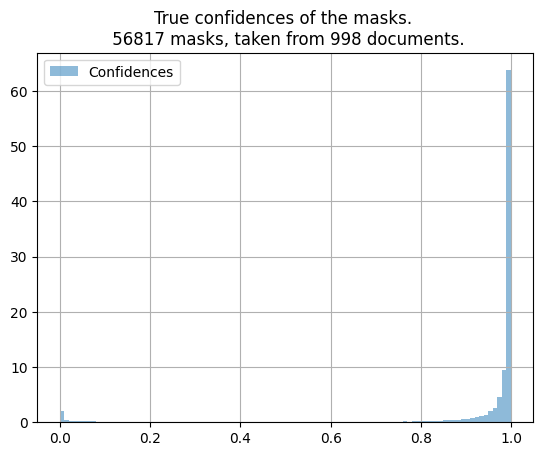

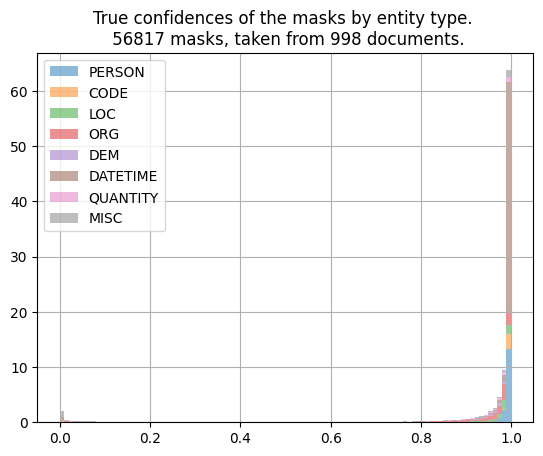

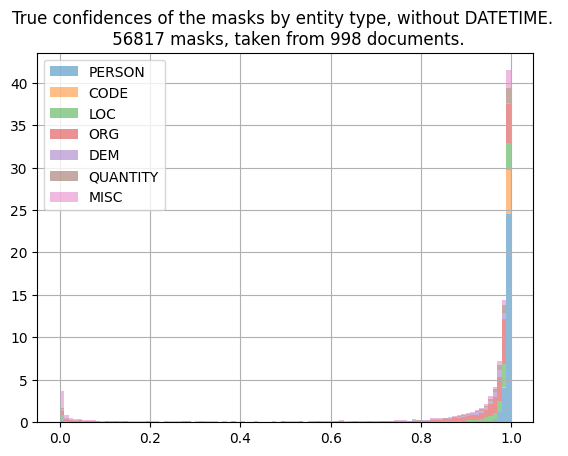

In [16]:
entity_string_to_int  = {
    'O': -1,
    'PERSON': 0,
    'CODE': 1,
    'LOC': 2,
    'ORG': 3,
    'DEM': 4,
    'DATETIME': 5,
    'QUANTITY': 6,
    'MISC': 7
}

entity_int_to_string = {v: k for k, v in entity_string_to_int.items()}    

entity_wise_true_probs = np.load( './true_probs_of_all_dict.npy', allow_pickle=True).item() 
entity_labels, entity_hist = zip(*entity_wise_true_probs.items())
entity_labels = [entity_int_to_string[el] for el in entity_labels]
n_seen_masks = 56817
n_diff_docs = 998


plt.figure()
plt.hist([e for entity_conf in entity_hist for e in entity_conf], bins = 100, density = True, alpha = 0.5, label = 'Confidences')
plt.grid()        
plt.legend()
title_string2 = f'True confidences of the masks. \n {n_seen_masks} masks, taken from {n_diff_docs} documents.'
plt.title(title_string2)
plt.show()
#plt.savefig( self.figpath + 'context_free_confidence_histogram.svg')


plt.figure()
plt.hist(entity_hist, bins = 100, density = True, stacked = True, alpha=0.5, label = entity_labels)
title_string3 = f'True confidences of the masks by entity type. \n {n_seen_masks} masks, taken from {n_diff_docs} documents.'
plt.title(title_string3)
plt.legend()
plt.grid() 
plt.show()
#plt.savefig( self.figpath + 'context_free_confidence_entity_wise_histogram.svg')

filtered_pairs = [( hist, label) for label, hist in zip(entity_labels, entity_hist) if label != "DATETIME"]
entity_hist_no_datetime, entity_labels_no_datetime = zip(*filtered_pairs)

plt.figure()
plt.hist(entity_hist_no_datetime, bins = 100, density = True, stacked = True, alpha=0.5, label = entity_labels_no_datetime)
title_string4 = f'True confidences of the masks by entity type, without DATETIME. \n {n_seen_masks} masks, taken from {n_diff_docs} documents.'
plt.title(title_string4)
plt.legend()
plt.grid() 
plt.show()
#plt.savefig( self.figpath + 'context_free_confidence_entity_wise_histogram_no_datetime.svg')


In [ ]:
entity_wise_true_probs = np.load( './true_probs_of_all_dict.npy', allow_pickle=True).item() 
print(entity_wise_probs.keys())


dict_keys([0, 1, 2, 3, 4, 5, 6, 7])


In [2]:
import numpy as np
import matplotlib.pyplot as plt

entity_string_to_int  = {
    'O': -1,
    'PERSON': 0,
    'CODE': 1,
    'LOC': 2,
    'ORG': 3,
    'DEM': 4,
    'DATETIME': 5,
    'QUANTITY': 6,
    'MISC': 7
}
entity_types_of_interest = ["QUANTITY", 'MISC', 'DEM', 'LOC']
entity_int_to_string = {v: k for k, v in entity_string_to_int.items()}    

attack_type_all = 'bandit'
attack_type_single = 'random'
experiment_output_folder = '/Users/reimera/Desktop/alvis/projects/LeakPro/examples/extraction_attacks/experiment_outputs'

window_extension = 5
doc_id = 985

if window_extension == 0:
    path_to_data = '/Users/reimera/Desktop/alvis/projects/LeakPro/examples/extraction_attacks' # For the original context free
else: 
    path_to_data = experiment_output_folder + f'/250918/1742_{attack_type_all}_gather_stats_size_ext_{window_extension}'



entity_wise_true_probs = np.load( '/Users/reimera/Desktop/alvis/projects/LeakPro/examples/extraction_attacks/experiment_outputs/250925/1452_random_gather_stats_size_ext_0/entity_wise_probs_two_mask_exp_all_docs.npy', allow_pickle=True).item() 
true_probs = np.load('/Users/reimera/Desktop/alvis/projects/LeakPro/examples/extraction_attacks/experiment_outputs/250925/1452_random_gather_stats_size_ext_0/true_probs_of_all_two_mask_exp_dict_all_docs.npy', allow_pickle=True).item() 


entity_labels, entity_hist = zip(*entity_wise_true_probs.items())
true_labels, true_hist = zip(*true_probs.items())


n_seen_masks = 56817
n_diff_docs = 998

# We're going to create a confusion matrix, where the entries are CONF[m1 |m2 = correct] - CONF[m1 |m2 = incorrect]
confidence_matrix_m2_incorrect = np.zeros((len(entity_string_to_int)-1, len(entity_string_to_int)-1))
confidence_matrix_m2_correct = np.zeros((len(entity_string_to_int)-1, len(entity_string_to_int)-1))

for i, l in enumerate(entity_labels):
    
    m1, m2 = str.split(l, '_')
    m1 = int(m1)
    m2 = int(m2)

    confidence_matrix_m2_incorrect[m1, m2] = np.mean([e for e in entity_hist[i] ])
    confidence_matrix_m2_correct[m1, m2] = np.mean([e for e in true_hist[i] ])
   

    
conf_matrix_difference = confidence_matrix_m2_correct - confidence_matrix_m2_incorrect

    

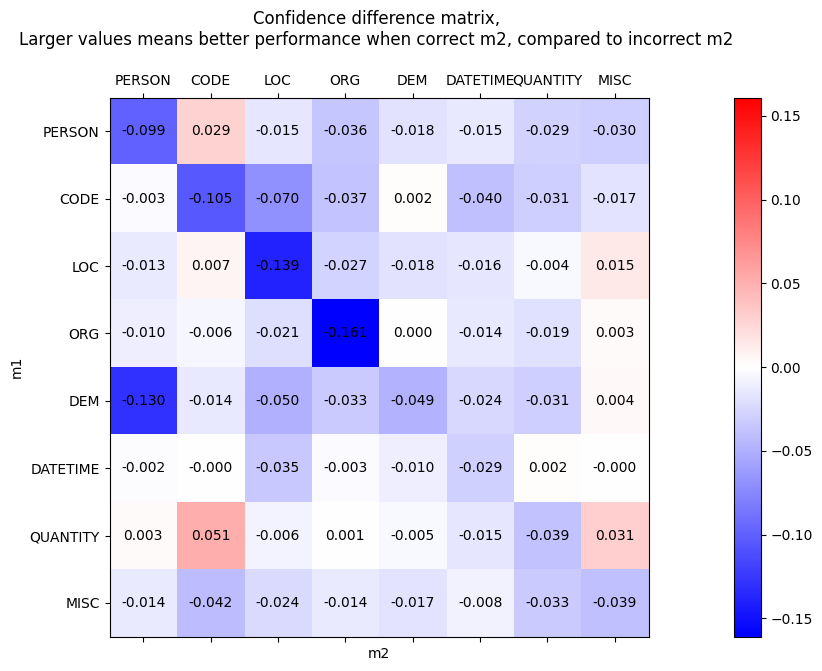

In [5]:
fig, ax = plt.subplots(figsize=(11,7))
max_val = np.max(np.abs(conf_matrix_difference))
cax = ax.matshow(conf_matrix_difference, cmap="bwr", vmin = -max_val, vmax = max_val)

# add colorbar
plt.colorbar(cax, pad = 0.1)

# set ticks
ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([entity_int_to_string[e] for e in range(8)])
ax.set_yticklabels([entity_int_to_string[e] for e in range(8)])

ax.set_xlabel("m2")
ax.set_ylabel("m1")
plt.title(f'Confidence difference matrix, \nLarger values means better performance when correct m2, compared to incorrect m2 \n')
# annotate cells
for i in range(8):
    for j in range(8):
        val = conf_matrix_difference[i, j]

        if val != 0:  # annotate only non-zero
            ax.text( j, i, f"{val:.3f}", va='center', ha='center', color="black")


plt.show()

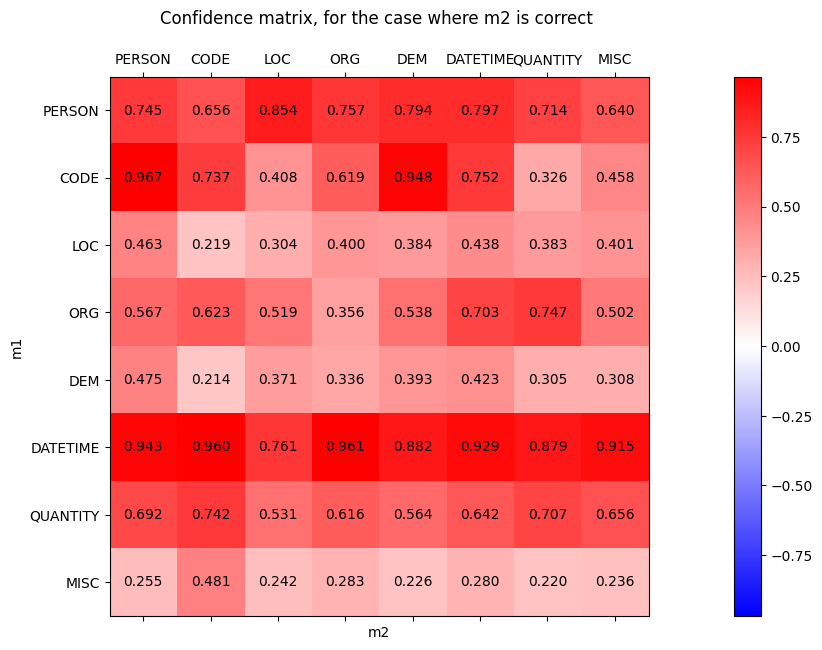

In [8]:
fig, ax = plt.subplots(figsize=(11,7))
max_val = np.max(np.abs(confidence_matrix_m2_correct))
cax = ax.matshow(confidence_matrix_m2_correct, cmap="bwr", vmin = -max_val, vmax = max_val)

# add colorbar
plt.colorbar(cax, pad = 0.1)

# set ticks
ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([entity_int_to_string[e] for e in range(8)])
ax.set_yticklabels([entity_int_to_string[e] for e in range(8)])

ax.set_xlabel("m2")
ax.set_ylabel("m1")
plt.title(f'Confidence matrix, for the case where m2 is correct \n')
# annotate cells
for i in range(8):
    for j in range(8):
        val = confidence_matrix_m2_correct[i, j]

        if val != 0:  # annotate only non-zero
            ax.text( j, i, f"{val:.3f}", va='center', ha='center', color="black")


plt.show()

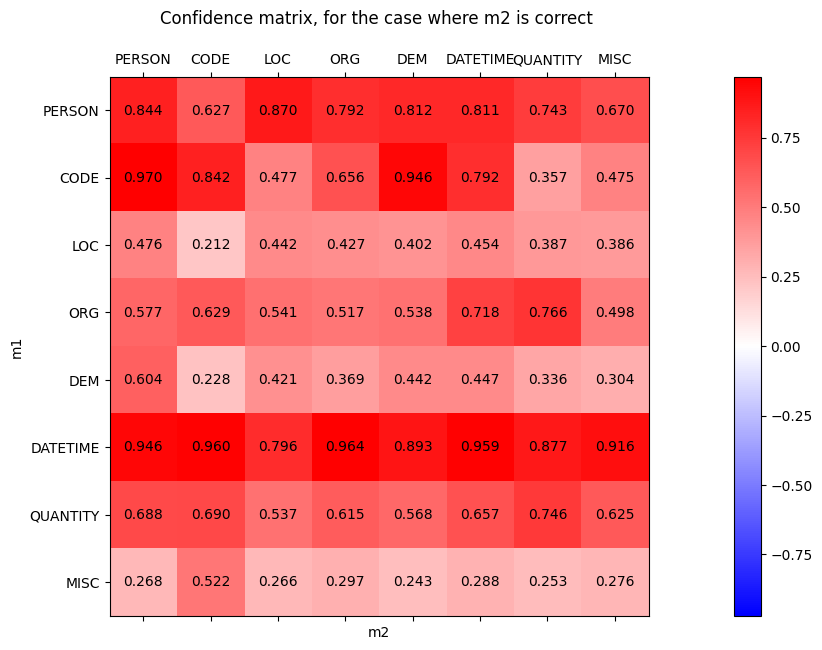

In [ ]:
fig, ax = plt.subplots(figsize=(11,7))
max_val = np.max(np.abs(confidence_matrix_m2_incorrect))
cax = ax.matshow(confidence_matrix_m2_incorrect, cmap="bwr", vmin = -max_val, vmax = max_val)

# add colorbar
plt.colorbar(cax, pad = 0.1)

# set ticks
ax.set_xticks(np.arange(8))
ax.set_yticks(np.arange(8))
ax.set_xticklabels([entity_int_to_string[e] for e in range(8)])
ax.set_yticklabels([entity_int_to_string[e] for e in range(8)])

ax.set_xlabel("m2")
ax.set_ylabel("m1")
plt.title(f'Confidence matrix, for the case where m2 is incorrect \n')
# annotate cells
for i in range(8):
    for j in range(8):
        val = confidence_matrix_m2_incorrect[i, j]

        if val != 0:  # annotate only non-zero
            ax.text( j, i, f"{val:.3f}", va='center', ha='center', color="black")


plt.show()